This jupiter notebook documents the processes needed to complete the first practical assignment.

Chosen dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction?resource=download

This particular dataset was chosen because it containts data that can be easily interpreted and an end goal (target variable) is pretty intuitive.

ST85021
4302BDA

# Data and library initialization

In [792]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.exceptions import ConvergenceWarning

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l1, l2, l1_l2

warnings.filterwarnings('ignore',category=ConvergenceWarning)

In [793]:
#df = pd.read_csv('/home/stw1z/data_IIS/heart.csv')
df = pd.read_csv('/content/heart.csv')
df.head(20)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [794]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


# Data vectorization and preparation for the problem of classification

Checking data for duplicates

In [795]:
print("Duplicate count: ", df.duplicated().sum())

Duplicate count:  0


Checking for missing data

In [796]:
print("Amount of NA data:\n", df.isna().sum())
print("\nAmount of null data:\n",df.isnull().sum())

Amount of NA data:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Amount of null data:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## Feature encoding

Converting "sex" to categorical "sex_m" (1 - male; 0 - female), one-hot encoding seems wrong to use here

In [797]:
df["Sex_m"] = df["Sex"].map({"M": 1, "F": 0})
df = df.drop(columns = "Sex")

Using one-hot encoding to split the feature "ChestPainType" into four

In [798]:
print("Unique values: ", df["ChestPainType"].value_counts(dropna=False).head(10))
df = pd.get_dummies(df, columns=["ChestPainType"], drop_first=True, dtype=int)

Unique values:  ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


Using one-hot encoding to split the feature "RestingECG" into three

In [799]:
print("Unique values: ", df["RestingECG"].value_counts(dropna=False).head(10))
df = pd.get_dummies(df, columns=["RestingECG"], drop_first=True, dtype=int)

Unique values:  RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


Using one-hot encoding to split the feature "ST_Slope" into three

In [800]:
print("Unique values: ", df["ST_Slope"].value_counts(dropna=False).head(10))
df = pd.get_dummies(df, columns=["ST_Slope"], drop_first=True,dtype=int)

Unique values:  ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


Encoding "ExerciseAngina" into categorical values

In [801]:
df["ExerciseAngina"] = df["ExerciseAngina"].map({"N":0,"Y":1})

So after performing one-hot encoding the dataset has this structure

In [802]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   ExerciseAngina     918 non-null    int64  
 6   Oldpeak            918 non-null    float64
 7   HeartDisease       918 non-null    int64  
 8   Sex_m              918 non-null    int64  
 9   ChestPainType_ATA  918 non-null    int64  
 10  ChestPainType_NAP  918 non-null    int64  
 11  ChestPainType_TA   918 non-null    int64  
 12  RestingECG_Normal  918 non-null    int64  
 13  RestingECG_ST      918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(1), int64(15)
m

# Data visualisation

## Histograms

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>, <Axes: >]], dtype=object)

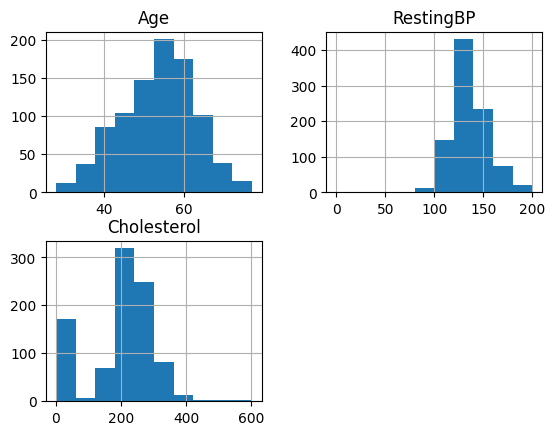

In [803]:
df[["Age", "RestingBP", "Cholesterol"]].hist()

array([[<Axes: title={'center': 'Oldpeak'}>,
        <Axes: title={'center': 'MaxHR'}>]], dtype=object)

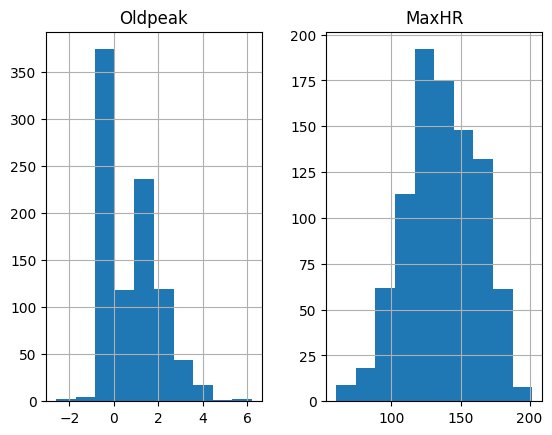

In [804]:
df[["Oldpeak", "MaxHR"]].hist()

## Boxplots

<Axes: xlabel='HeartDisease', ylabel='Age'>

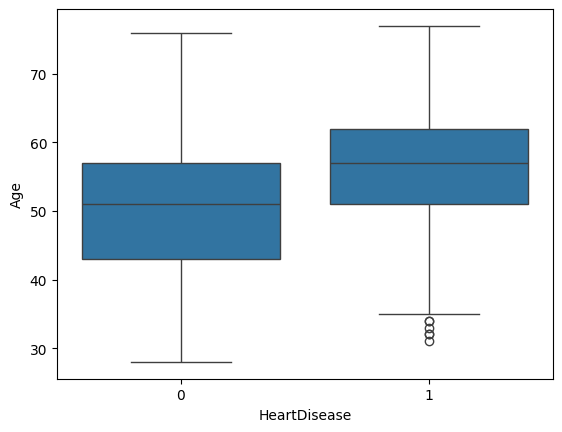

In [805]:
sns.boxplot(x="HeartDisease", y="Age", data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

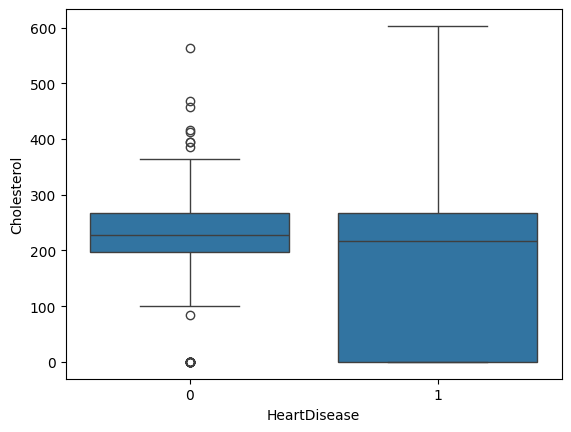

In [806]:
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df)

<Axes: >

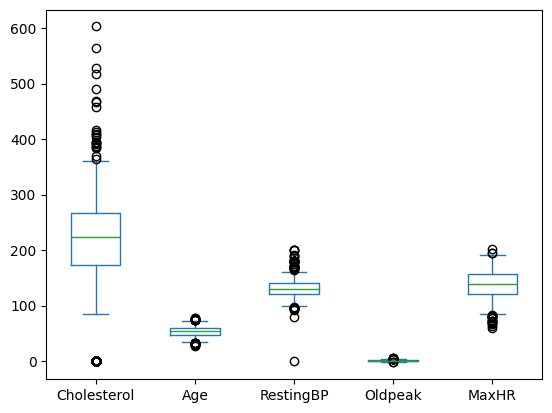

In [807]:
df[["Cholesterol", "Age","RestingBP", "Oldpeak", "MaxHR"]].plot.box(whis=1)

Based on the boxplot a few points can be interpreted:
1) RestingBP contains values close to 0 - which is impossible for any living person (data will be imputed using the mean)
2) "Cholesterol" has a lot of outliers, but since its actual medical data they are valid
3) Some features are very skewed and require transformation or normalization

<Axes: >

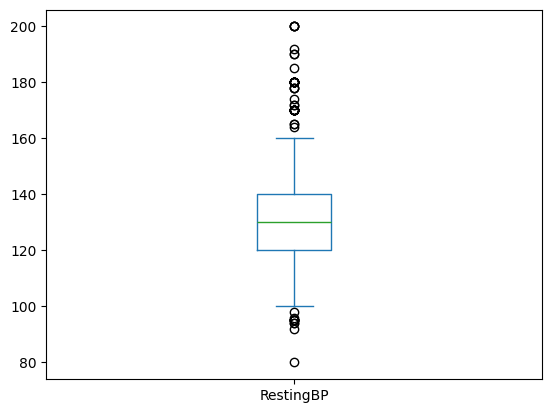

In [808]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].mean())
df["RestingBP"].plot.box(whis=1)

## Data normalization (Cholesterol)

<Axes: >

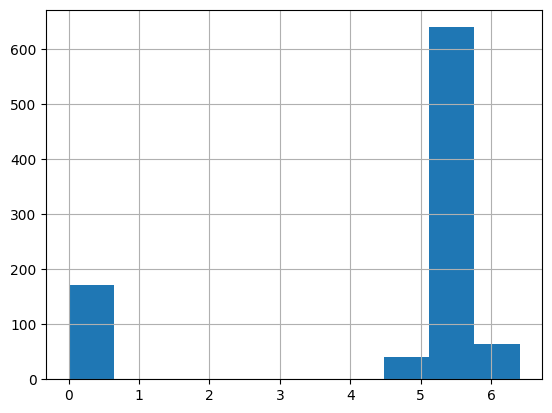

In [809]:
df["Cholesterol"] = np.log1p(df["Cholesterol"])
df['Cholesterol'].hist()

# Feature correlation analysis

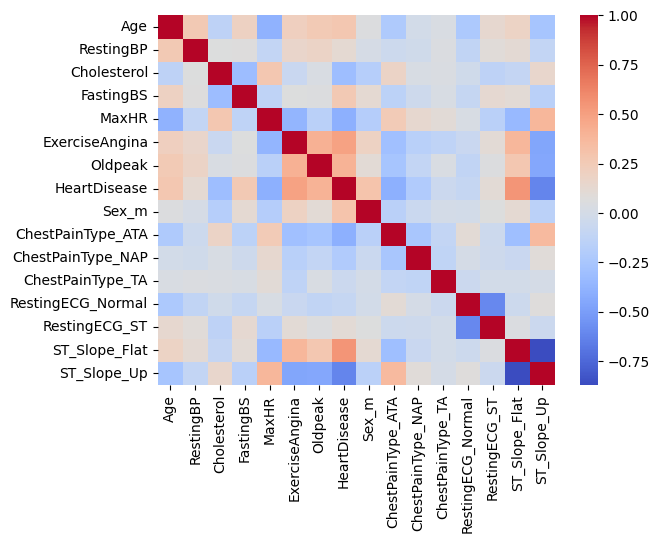

In [810]:
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [811]:
df.corr()["HeartDisease"].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
ST_Slope_Flat,0.554134
ExerciseAngina,0.494282
Oldpeak,0.403951
Sex_m,0.305445
Age,0.282039
FastingBS,0.267291
RestingBP,0.117938
RestingECG_ST,0.102527
ChestPainType_TA,-0.054790


### Categorical features vs Target feature (Heart Disease)

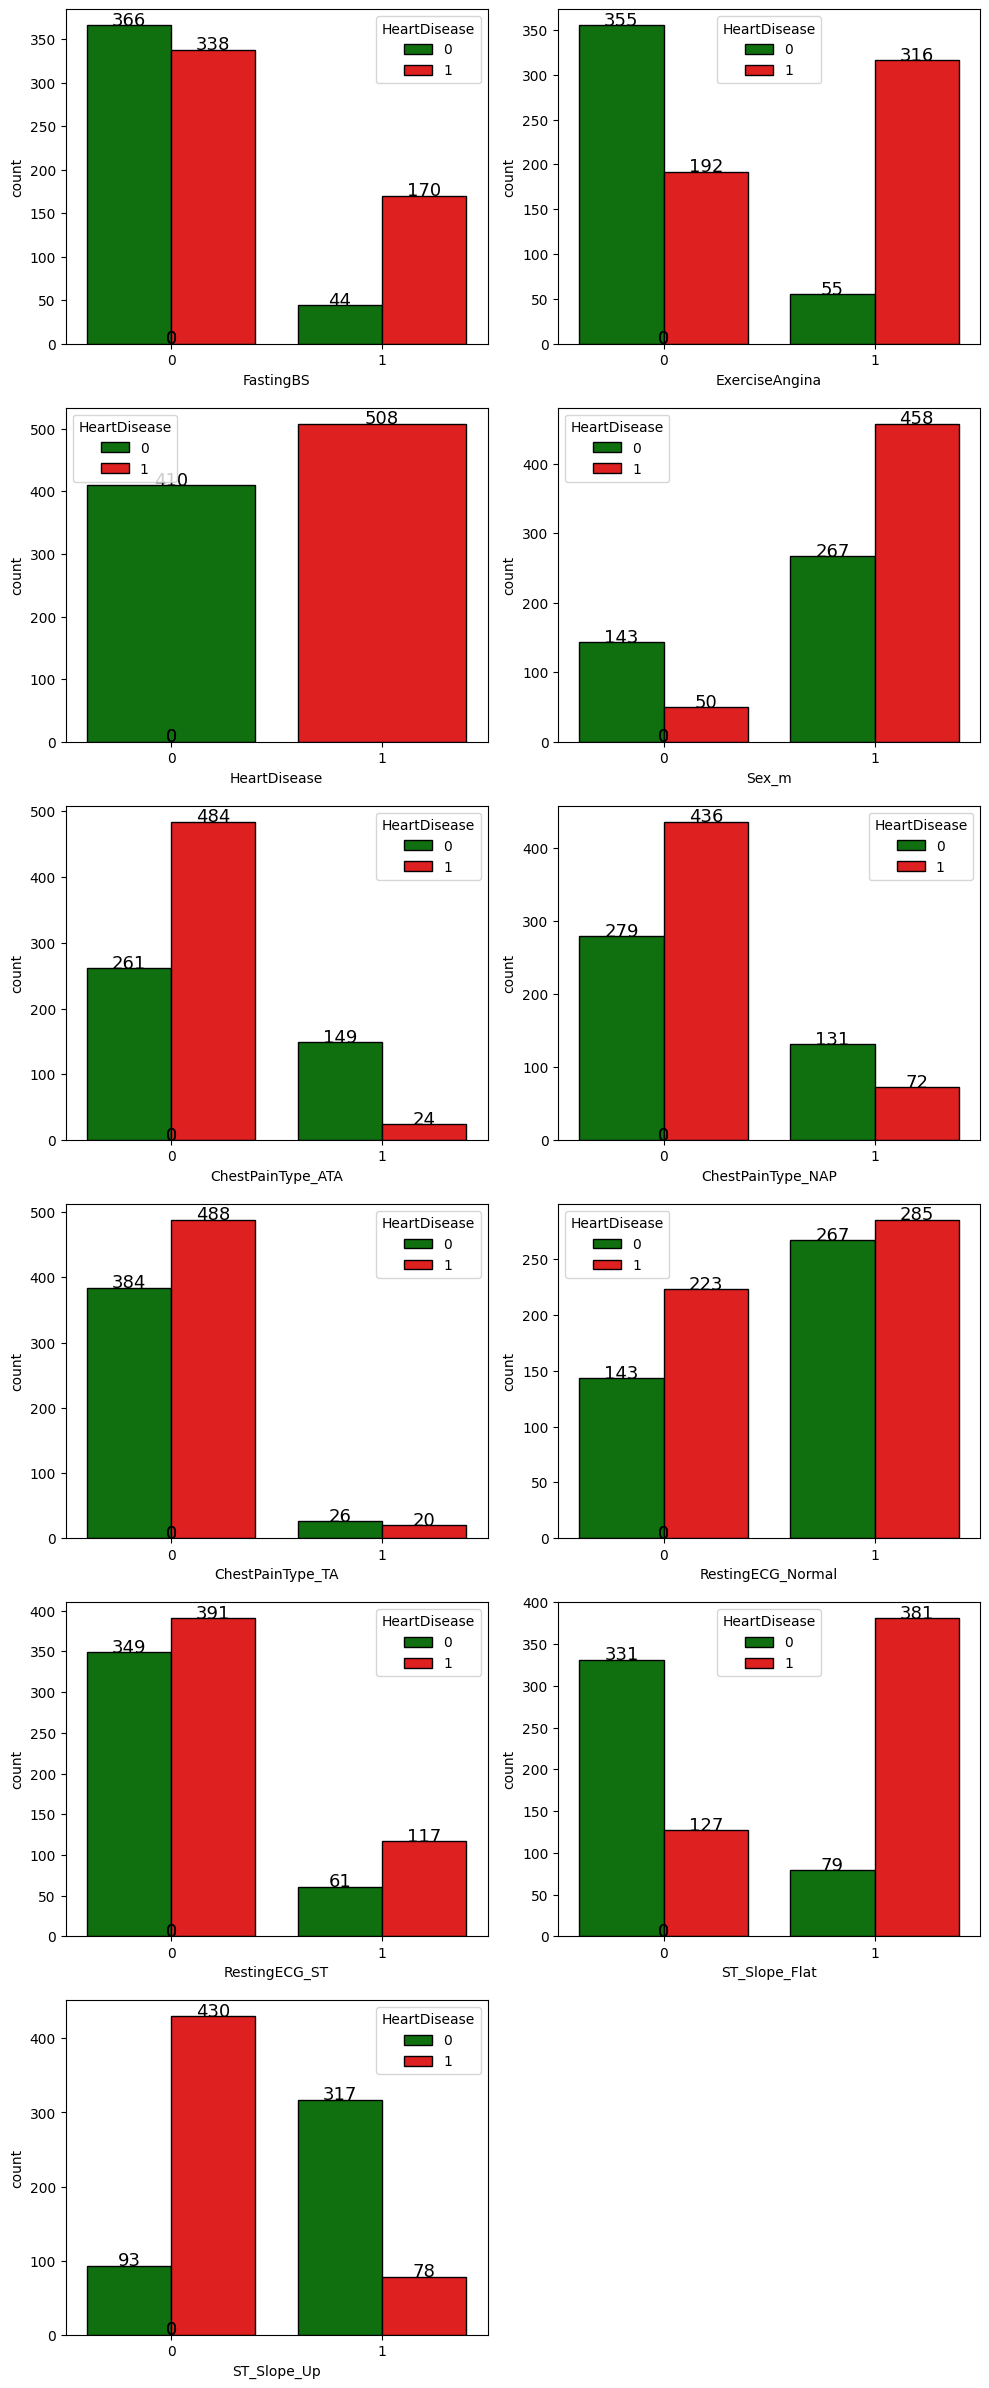

In [812]:
col = list(df.columns)
cat_features = []
num_features = []
colors = ['green', 'red']

for i in col:
    if len(df[i].unique()) > 2:
        num_features.append(i)
    else:
        cat_features.append(i)

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(10,24))
axes = axes.flatten()

for i in range(len(cat_features)):
    ax = axes[i]

    sns.countplot(
        x = cat_features[i],
        data = df,
        hue = 'HeartDisease',
        palette = colors,
        edgecolor = 'black',
        ax = ax)

    for rect in ax.patches:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height(),
            str(int(rect.get_height())),
            ha='center',
            fontsize = 13)

    title = cat_features[i] + 'vs HeartDisease'
    plt.legend(['Healthy Heart', 'Heart Disease'])
    plt.title(title)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


ExerciseAngina = 1 is strongly associated with heart disease.
ST_Slope_Flat = 1 is also strongly linked to heart disease, while ST_Slope_Up = 1 is mostly associated with healthy patients.

Men (Sex_m = 1) show a higher rate of heart disease than women.
FastingBS = 1 is linked to increased risk.

ChestPainType_ATA = 1 is mostly associated with healthy patients, while NAP is slightly associated with being healthier. TA shows a weak relationship.

RestingECG_ST = 1 is associated with higher heart disease, while RestingECG_Normal shows a weak or mixed relationship.

Overall, the strongest indicators are ST_Slope, ExerciseAngina, and certain chest pain types.


### Stripplots

<Axes: xlabel='ST_Slope_Flat', ylabel='Oldpeak'>

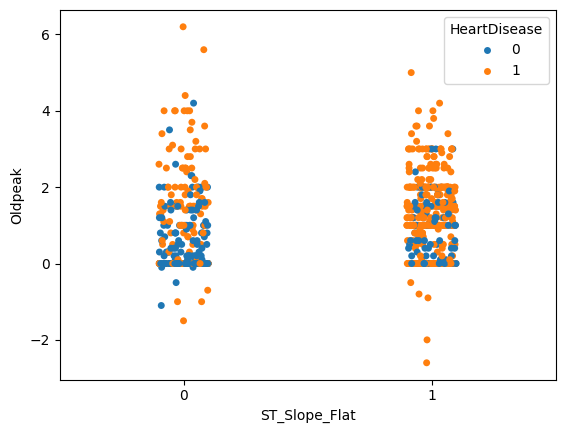

In [813]:
sns.stripplot(x="ST_Slope_Flat", y="Oldpeak", hue="HeartDisease", data=df, jitter = True)

<Axes: xlabel='ExerciseAngina', ylabel='Oldpeak'>

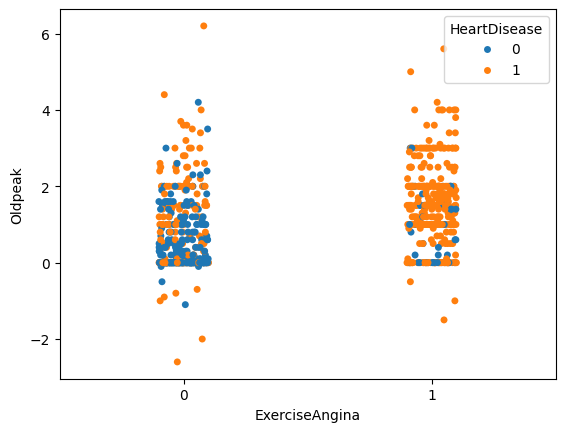

In [814]:
sns.stripplot(x="ExerciseAngina", y="Oldpeak", hue="HeartDisease", data=df, jitter = True)

<Axes: xlabel='ST_Slope_Up', ylabel='MaxHR'>

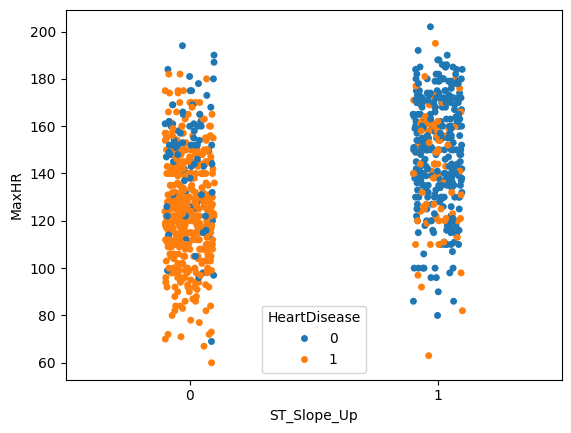

In [815]:
sns.stripplot(x="ST_Slope_Up", y="MaxHR", hue="HeartDisease", data=df, jitter = True)

Graphs interpretation:

The plots show that heart disease is strongly associated with specific patterns:
    
    Higher Oldpeak values consistently correspond to a higher likelihood of disease

    ExerciseAngina and a flat ST slope are both clear indicators of increased risk when present.

    An upward ST slope and higher MaxHR are associated with a lower likelihood of disease.
    
    Overall, the combination of binary features (ExerciseAngina, ST slope types) with continuous features (Oldpeak, MaxHR) provides strong separation between patients with and without heart disease.


# Splitting data 80/20, scaling X_train and X_test and converting to numpy arrays

In [816]:
X = df.drop('HeartDisease', axis = 1)
Y = df['HeartDisease']

X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.2,
    random_state = 67, #hah 67 again!
    stratify = Y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train_raw = X_train_raw.to_numpy()
X_test_raw = X_test_raw.to_numpy()

Y_train = Y_train.to_numpy()
Y_test = Y_test.to_numpy()

## Reusable cross validation score function for decision trees (no scaling)

In [817]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=17, random_state=1, shuffle=True)

def getTreeCrossScore(model):
  scores = cross_val_score(
      model,
      X_train_raw,
      Y_train,
      cv=cv,
      scoring='accuracy'
  )
  return scores.mean()

# Decision tree creation and performance evaluation

## Simple decision tree training

In [818]:
dtree = DecisionTreeClassifier(max_depth=5, random_state=67)
dtree.fit(X_train_raw,Y_train)

scores_t = getTreeCrossScore(dtree)

train_pred = dtree.predict(X_train_raw)
test_pred = dtree.predict(X_test_raw)

train_acc_t = accuracy_score(Y_train, train_pred)
test_acc_t = accuracy_score(Y_test, test_pred)

print('train accuracy: ', train_acc_t)
print('test accuracy: ', test_acc_t)
print('cross validation accuracy: ', scores_t)


train accuracy:  0.8978201634877384
test accuracy:  0.842391304347826
cross validation accuracy:  0.8297786344981967


## Hyperparameter tuning using

- criterion can be either "gini" or "entropy"
- max_depth is an integer
- min_samples_leaf is the amount of patients each leaf of the tree has to hold
- best parameters are chosen based on the cross-validation scores of the models

In [819]:
best_cv= 0

for criterion in ['gini', 'entropy', 'log_loss']:
    for max_depth in range(1,20):
        for min_samples_leaf in range(1,20):
            dtree_h = DecisionTreeClassifier(max_depth=max_depth, criterion = criterion, min_samples_leaf=min_samples_leaf)
            cv_score = getTreeCrossScore(dtree_h)

            if cv_score > best_cv:
                best_params = {
                    "criterion": criterion,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf
                }
                best_cv = cv_score
print("Best parameters: ", best_params)
print("Best cross validation score: ", best_cv)

Best parameters:  {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 11}
Best cross validation score:  0.8447954234547941


## Decision tree with best parameters

In [820]:
dtree_best = DecisionTreeClassifier(criterion = best_params["criterion"], max_depth=best_params["max_depth"], min_samples_leaf=best_params["min_samples_leaf"])

dtree_best.fit(X_train_raw, Y_train)
test_predict = dtree_best.predict(X_test_raw)
test_accuracy_tBest = accuracy_score(Y_test, test_predict)
train_accuracy_tBest = accuracy_score(Y_train, dtree_best.predict(X_train_raw))

scores_tBest = getTreeCrossScore(dtree_best)

print("train accuracy: ", train_accuracy_tBest)
print("test accuracy: ", test_accuracy_tBest)
print('cross validation accuracy: ', scores_tBest)

train accuracy:  0.8787465940054496
test accuracy:  0.8369565217391305
cross validation accuracy:  0.8447954234547941


## Visualising the Tree structure

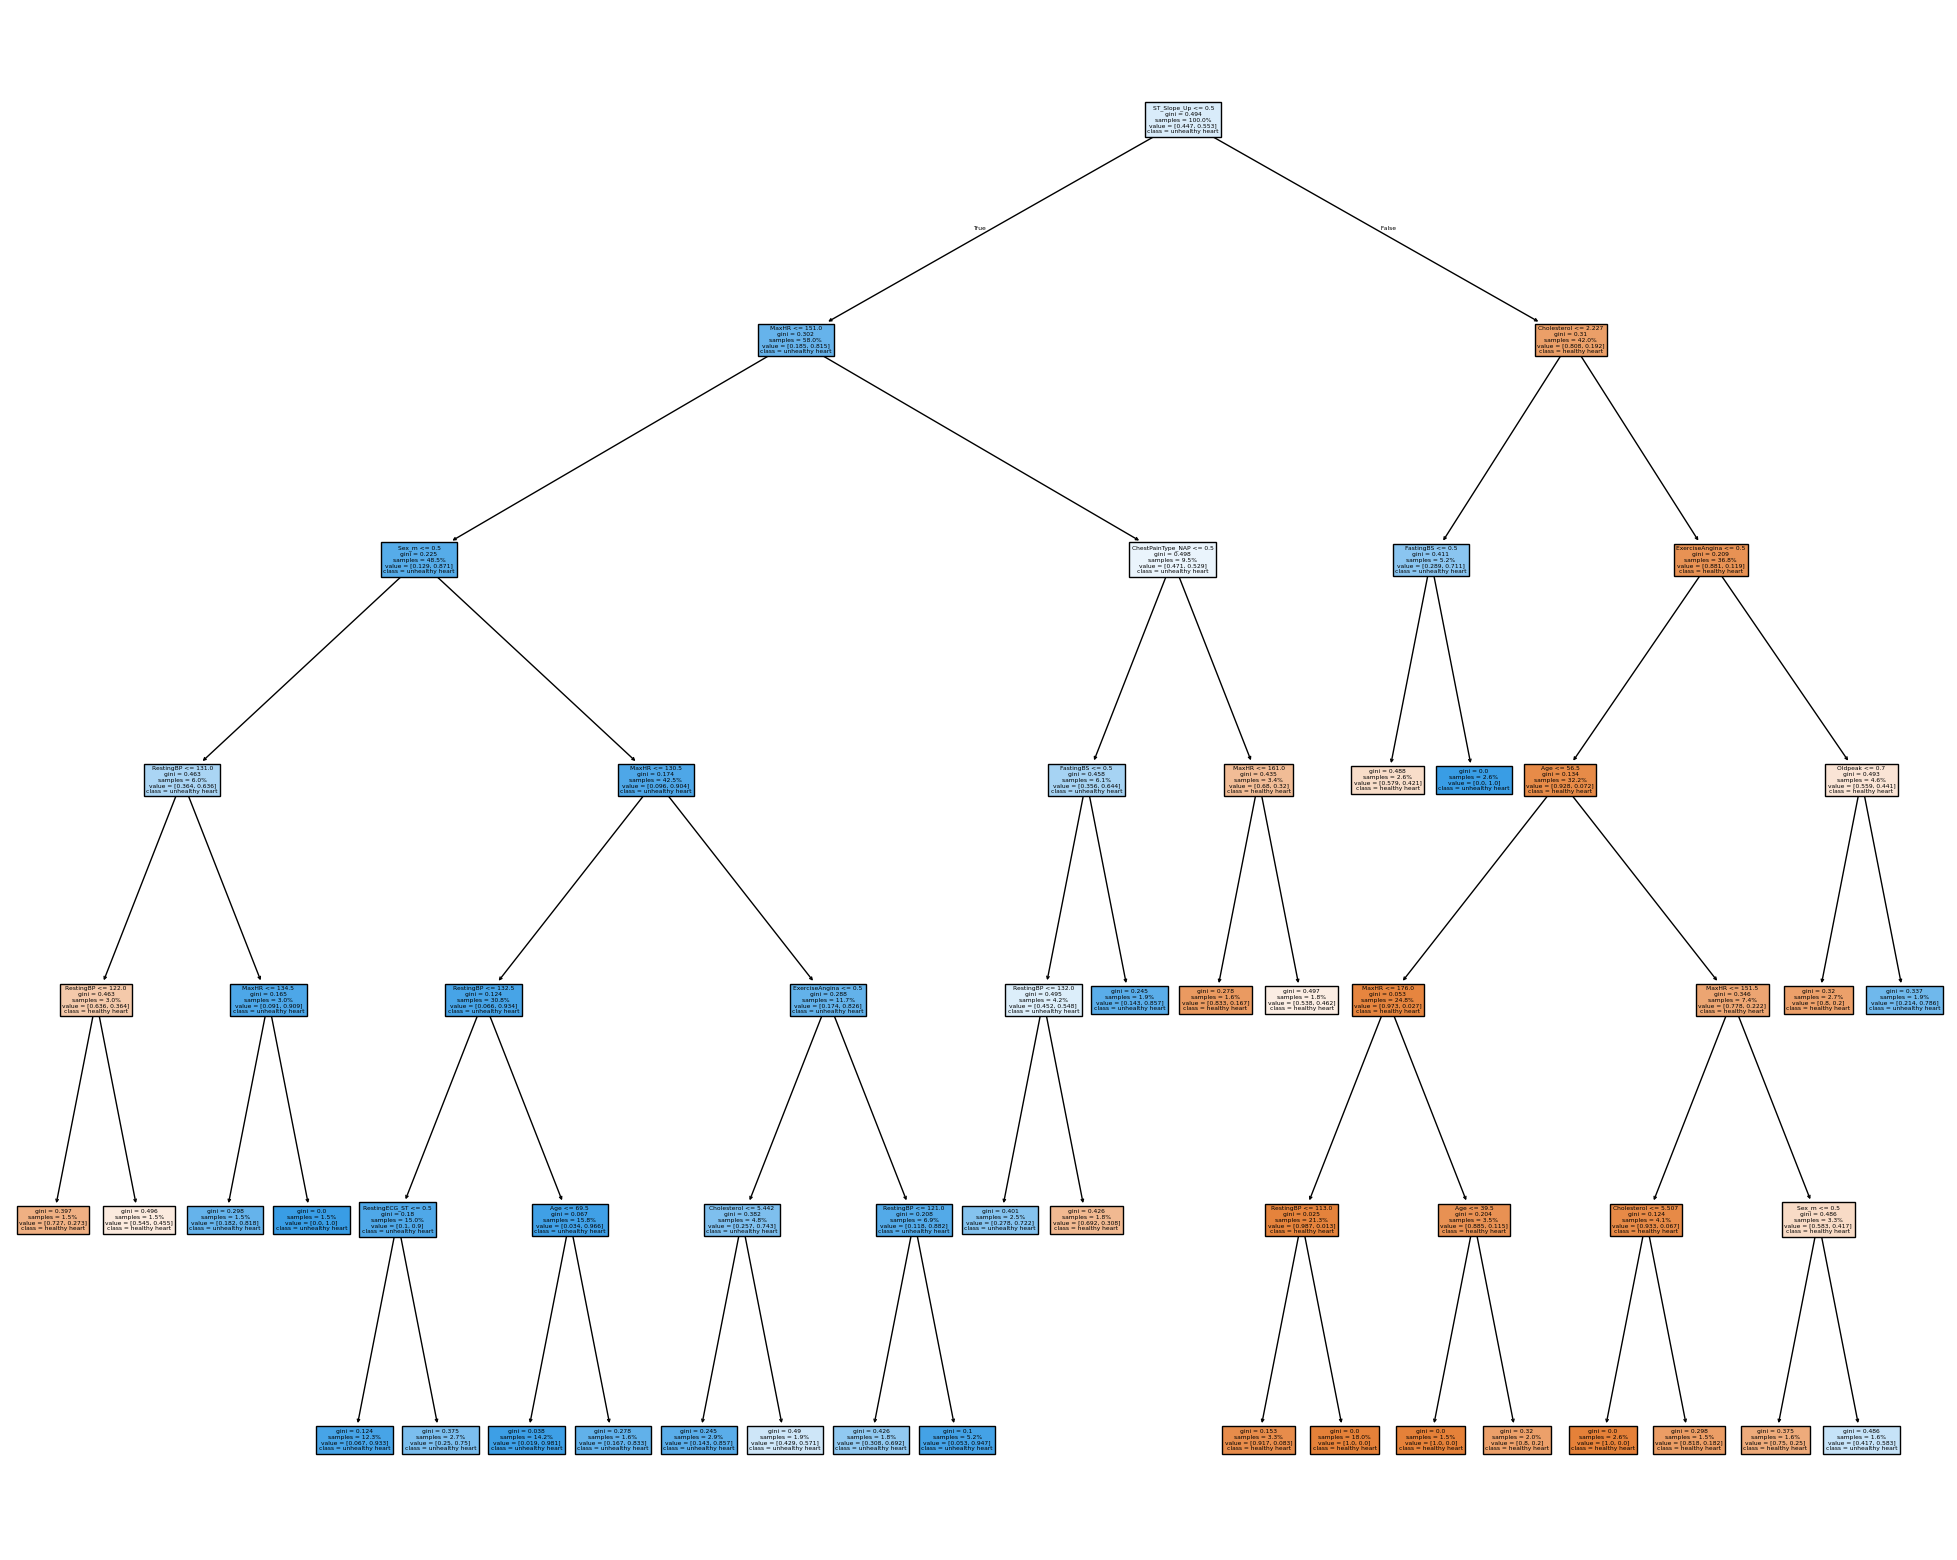

In [821]:
from sklearn.tree import plot_tree

fig = plt.figure(figsize=((25,20)))
plot_tree(dtree_best,
    feature_names = X.columns,
    class_names = ["healthy heart", "unhealthy heart"],
    impurity = True,
    proportion = True,
    filled = True)

fig.savefig("tree_best")

# Logistic Regression

## Reusable cross validation score function for logistic regression (with scaling)

In [822]:
def getLRCrossScore(model):
  scores = []

  for train_idx, val_idx in cv.split(X_train_raw, Y_train): #creates indices for train and validation data inside each cross-validation fold/split
    scaler = StandardScaler() #new scaler per fold/split
    X_train_fold = scaler.fit_transform(X_train_raw[train_idx]) #fits scaler on training fold/split and transform training data
    X_val_fold = scaler.transform(X_train_raw[val_idx]) #applies transform only for validation folds/splits using statistics learned from training fold/split

    model.fit(X_train_fold, Y_train[train_idx]) #trains model on train indices only
    scores.append(model.score(X_val_fold, Y_train[val_idx])) #evaluates model performance on validation data not seen in this fold/split

  return mean(scores)

In [823]:
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
best_solver = ''
test_score = np.zeros(6)
best_score = 0

cv = StratifiedKFold(n_splits=17, random_state=67, shuffle=True)

for i,n in enumerate(solver):
  lr = LogisticRegression(solver = n, max_iter=1000)
  cv_score = getLRCrossScore(lr)
  test_score[i] = cv_score
  if cv_score > best_score:
    best_score = cv_score
    best_solver = n

print('Score per solver: ')
for i,n in enumerate(solver):
    print(n, "scored: ", test_score[i])
print('\nBest solver: ', best_solver,'\n')

lr = LogisticRegression(solver=best_solver, max_iter=1000)
lr.fit(X_train_scaled, Y_train)
lr_pred = lr.predict(X_test_scaled)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

Score per solver: 
lbfgs scored:  0.8637607262778261
liblinear scored:  0.8637607262778261
newton-cg scored:  0.8637607262778261
newton-cholesky scored:  0.8637607262778261
sag scored:  0.8637607262778261
saga scored:  0.8637607262778261

Best solver:  lbfgs 



Different solvers were tested for the logistic regression model. All solvers produced identical performance, indicating stable convergence to the same optimal solution. Therefore, the choice of solver does not significantly impact the model performance on this dataset.

## Coefficients per feature + intercept

In [824]:
print(coef_df.sort_values(by="Coefficient", ascending=False))
print("\nIntercept: ", lr.intercept_)

              Feature  Coefficient
13      ST_Slope_Flat     0.626231
7               Sex_m     0.553407
5      ExerciseAngina     0.534407
3           FastingBS     0.392928
6             Oldpeak     0.241039
1           RestingBP     0.151563
0                 Age     0.134116
4               MaxHR    -0.048483
11  RestingECG_Normal    -0.148274
12      RestingECG_ST    -0.195456
10   ChestPainType_TA    -0.297211
8   ChestPainType_ATA    -0.552159
14        ST_Slope_Up    -0.626824
9   ChestPainType_NAP    -0.653566
2         Cholesterol    -0.713765

Intercept:  [0.35867502]


## Confusion matrix

In [825]:
lr_pred = lr.predict(X_test_scaled)
confusion_matrix(Y_test, lr_pred)

array([[73,  9],
       [15, 87]])

## Classification report

In [826]:
print(classification_report(Y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        82
           1       0.91      0.85      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



## Train, test and cross-validation accuracies

In [827]:
test_accuracy_lr = lr.score(X_test_scaled, Y_test)
train_accuracy_lr = lr.score(X_train_scaled, Y_train)
scores_lr = getLRCrossScore(lr)

print("train accuracy: ", train_accuracy_lr)
print("test accuracy: ", test_accuracy_lr)
print('cross validation accuracy: ', scores_lr)

train accuracy:  0.8760217983651226
test accuracy:  0.8695652173913043
cross validation accuracy:  0.8637607262778261


# Neural networks

### Setting seed value for controlled evaluations

In [828]:
import random
seed = 67
np.random.seed(seed)
tensorflow.random.set_seed(seed)
random.seed(seed)

Random seeds were fixed for NumPy, TensorFlow, and Python’s random module to ensure reproducibility of neural network training as much as possible.

### Reusable visualization and classification report + confusion matrix  function

In [829]:
def visualizeModel(model_history):
  history_dict = model_history.history

  acc = history_dict['accuracy']
  val_acc = history_dict['val_accuracy']

  loss = history_dict['loss']
  val_loss = history_dict['val_loss']

  epochs = range(1,len(acc)+1)

  plt.plot(epochs, acc, 'r', label='Training accuracy')
  plt.plot(epochs, val_acc,  'b', label='Validation accuracy')
  plt.title('Training and validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()


def getConfMatrix(model):
  predicts = model.predict(X_test_scaled)
  y_pred = (predicts > 0.5).astype(int).ravel()
  matrix = confusion_matrix(Y_test, y_pred)
  return print('\nClassification report:\n', classification_report(Y_test, y_pred)), print('\nConfusion matrix:\n', matrix)

## Baseline neural network model with 15 input features, one hidden layer with 16 neurons, relu activation, ouput layer with sigmoid activation and 50 epochs

In [830]:
n_columns = X_train_scaled.shape[1] # number of input features (15)

model_base = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_base.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_base = model_base.fit(
    X_train_scaled,
    Y_train,
    epochs = 50,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy visualisation

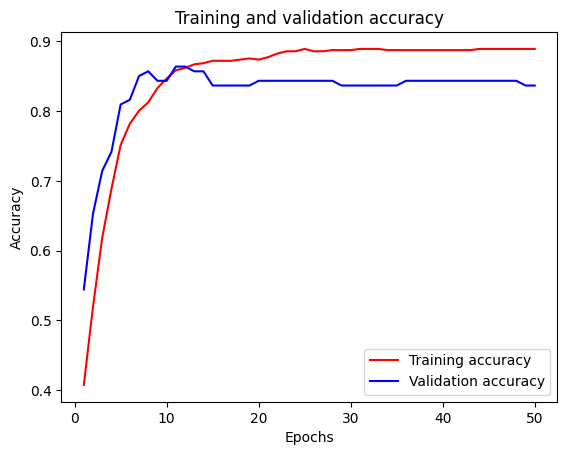

In [831]:
visualizeModel(history_base)

### Classification report and confusion matrix

In [832]:
getConfMatrix(model_base)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85        82
           1       0.89      0.86      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184


Confusion matrix:
 [[71 11]
 [14 88]]


(None, None)

## Same model but with 100 epochs

In [833]:
n_columns = X_train_scaled.shape[1] # number of input features (15)

model_epochs = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_epochs.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_epochs = model_epochs.fit(
    X_train_scaled,
    Y_train,
    epochs = 100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy

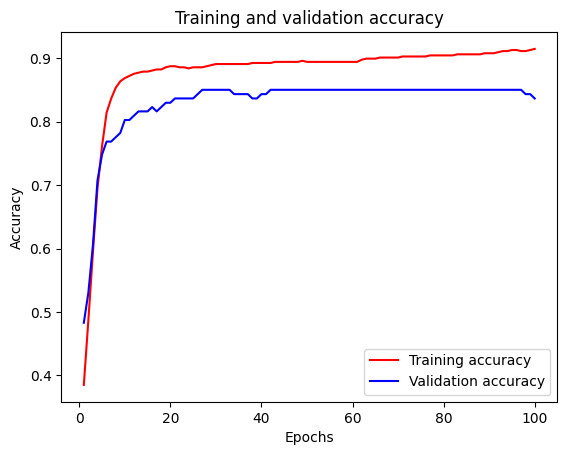

In [834]:
visualizeModel(history_epochs)

### Classification report and confusion matrix

In [835]:
getConfMatrix(model_epochs)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.89        82
           1       0.92      0.89      0.91       102

    accuracy                           0.90       184
   macro avg       0.89      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184


Confusion matrix:
 [[74  8]
 [11 91]]


(None, None)

## Same model but with dropout at 20%

In [836]:
model_dropout = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_dropout = model_dropout.fit(
    X_train_scaled,
    Y_train,
    epochs = 100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy visualisation

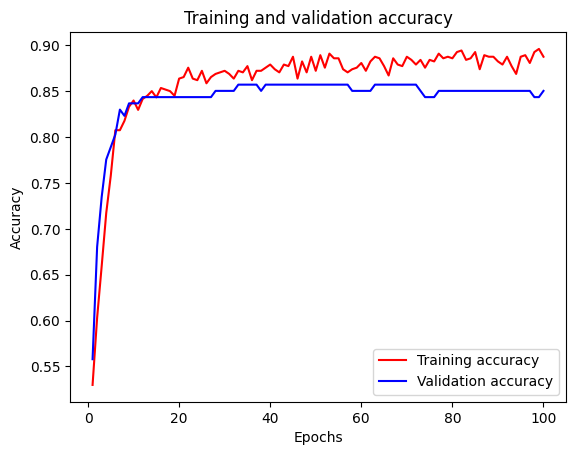

In [837]:
visualizeModel(history_dropout)

### Confusion matrix + classification report

In [838]:
getConfMatrix(model_dropout)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87        82
           1       0.91      0.88      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184


Confusion matrix:
 [[73  9]
 [12 90]]


(None, None)

## Same model but with L1 regularizer

In [839]:
model_l1 = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(16, activation='relu', kernel_regularizer=l1(1e-4)),
    Dense(1, activation='sigmoid')
])

model_l1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_l1 = model_l1.fit(
    X_train_scaled,
    Y_train,
    epochs = 100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy

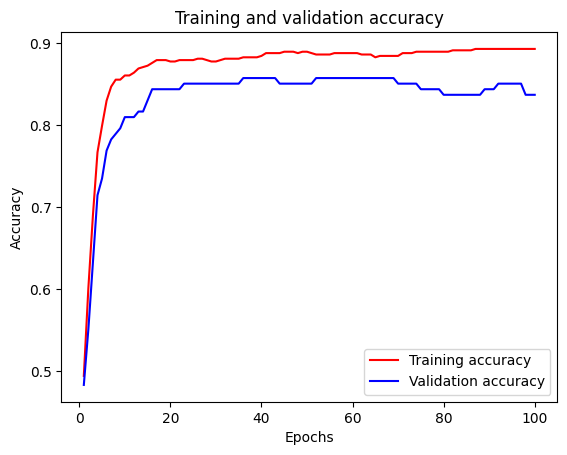

In [840]:
visualizeModel(history_l1)

### Classification report and confusion matrix

In [841]:
getConfMatrix(model_l1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88        82
           1       0.91      0.90      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184


Confusion matrix:
 [[73  9]
 [10 92]]


(None, None)

## Same model but with L2 regularizer at 20% instead

In [842]:
model_l2 = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(16, activation='relu', kernel_regularizer=l2(1e-5)),
    Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_l2 = model_l2.fit(
    X_train_scaled,
    Y_train,
    epochs = 100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy visualisation

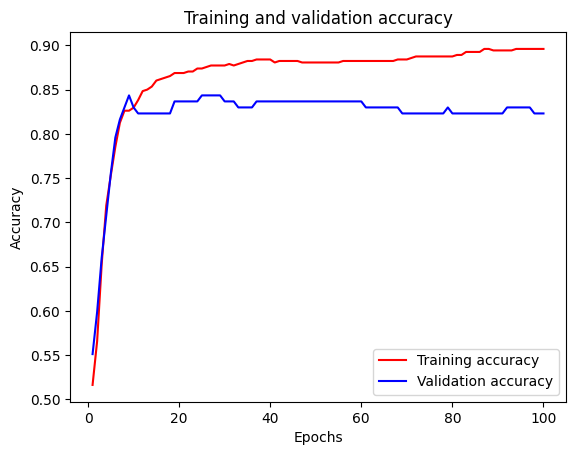

In [843]:
visualizeModel(history_l2)

### Classification report + confusion matrix

In [844]:
getConfMatrix(model_l2)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86        82
           1       0.91      0.85      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion matrix:
 [[73  9]
 [15 87]]


(None, None)

##

## Same model but with 30 neurons in the hidden layer

In [845]:
model_width = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(30, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_width.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_width = model_width.fit(
    X_train_scaled,
    Y_train,
    epochs = 100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy visualization

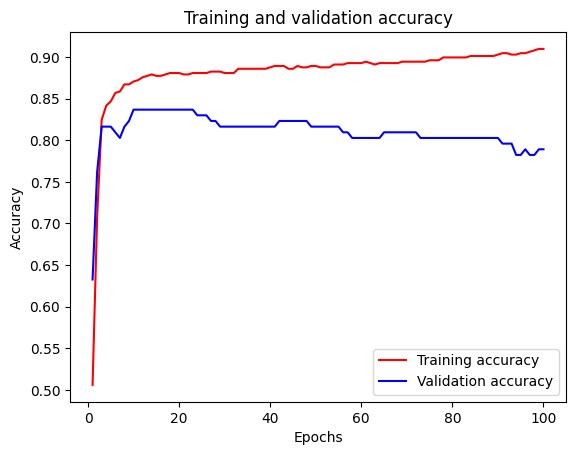

In [846]:
visualizeModel(history_width)

### Classification report and confusion matrix

In [847]:
getConfMatrix(model_width)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.88        82
           1       0.93      0.86      0.89       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


Confusion matrix:
 [[75  7]
 [14 88]]


(None, None)

## Multilayer model with three hidden layers with relu activation, 16 neurons per layer and sigmoid activation (no dropout or regularization)

In [848]:
model_depth = Sequential([
    keras.Input(shape=(n_columns,)),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_depth.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_depth = model_depth.fit(
    X_train_scaled,
    Y_train,
    epochs = 100,
    batch_size=32,
    shuffle=True,
    validation_split=0.2,
    verbose=0
    )

### Training and validation accuracy visualization

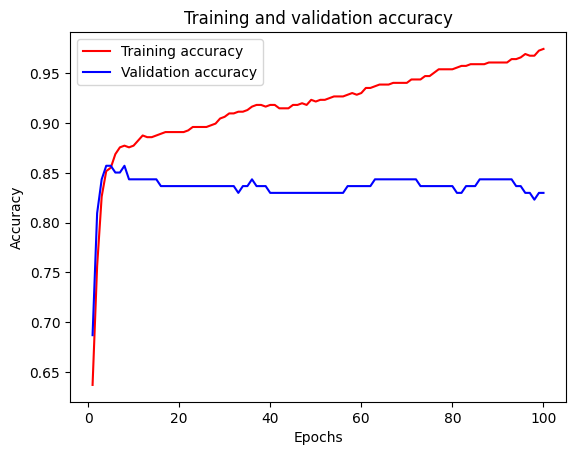

In [849]:
visualizeModel(history_depth)

### Classification report and confusion matrix

In [850]:
getConfMatrix(model_depth)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87        82
           1       0.93      0.85      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


Confusion matrix:
 [[75  7]
 [15 87]]


(None, None)

## Neural network model comparison

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8641 - loss: 0.2770 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8967 - loss: 0.2629 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8859 - loss: 0.2663 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8967 - loss: 0.2705 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8696 - loss: 0.2877 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8859 - loss: 0.2718 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8804 - loss: 0.3363 
                 Model  Train Accuracy  Test Accuracy  Validation Accuracy  \
0  Baseline, 50 epochs        0.889267       0.864130             0.863946   
1           100 epochs        0.914821       0.896739             0.850340   
2              Dropout        0.896082       0.885870             0.857143   
3                   L1        0.892675       0.896739             0.857143   
4                   L2        0.896082       0.869565             0.843537   
5                Width      

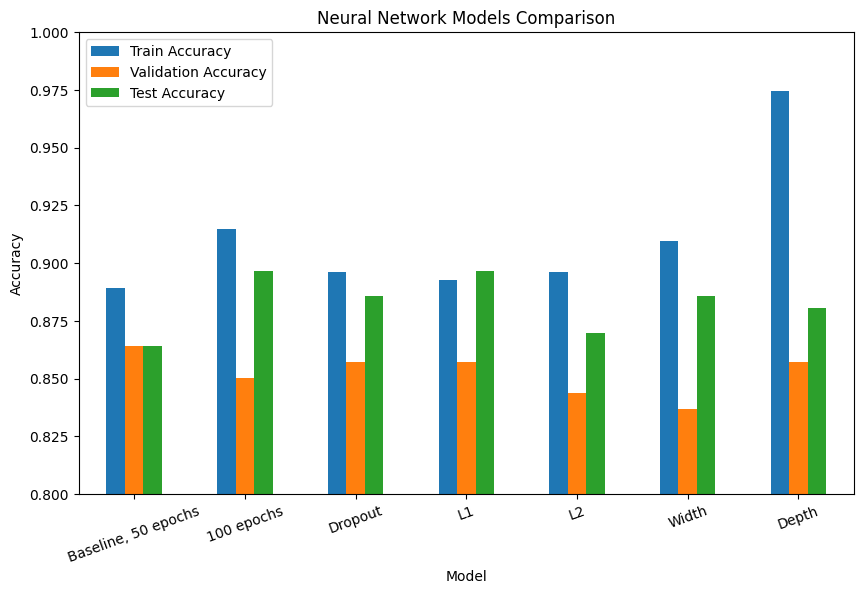

In [851]:
baseline_acc = model_base.evaluate(X_test_scaled, Y_test)[1]

summary_df = pd.DataFrame({
    'Model': ['Baseline, 50 epochs', '100 epochs' ,'Dropout', 'L1', 'L2', 'Width', 'Depth'],
    'Train Accuracy': [
        max(history_base.history['accuracy']),
        max(history_epochs.history['accuracy']),
        max(history_dropout.history['accuracy']),
        max(history_l1.history['accuracy']),
        max(history_l2.history['accuracy']),
        max(history_width.history['accuracy']),
        max(history_depth.history['accuracy'])
    ],
    'Test Accuracy': [
        baseline_acc,
        model_epochs.evaluate(X_test_scaled, Y_test)[-1],
        model_dropout.evaluate(X_test_scaled, Y_test)[-1],
        model_l1.evaluate(X_test_scaled, Y_test)[-1],
        model_l2.evaluate(X_test_scaled, Y_test)[-1],
        model_width.evaluate(X_test_scaled, Y_test)[-1],
        model_depth.evaluate(X_test_scaled, Y_test)[-1]
    ],
    'Validation Accuracy': [
        max(history_base.history['val_accuracy']),
        max(history_epochs.history['val_accuracy']),
        max(history_dropout.history['val_accuracy']),
        max(history_l1.history['val_accuracy']),
        max(history_l2.history['val_accuracy']),
        max(history_width.history['val_accuracy']),
        max(history_depth.history['val_accuracy'])
    ],
    'Train Loss': [
        history_base.history['loss'][-1],
        history_epochs.history['loss'][-1],
        history_dropout.history['loss'][-1],
        history_l1.history['loss'][-1],
        history_l2.history['loss'][-1],
        history_width.history['loss'][-1],
        history_depth.history['loss'][-1]
    ],
    'Validation Loss': [
        history_base.history['val_loss'][-1],
        history_epochs.history['val_loss'][-1],
        history_dropout.history['val_loss'][-1],
        history_l1.history['val_loss'][-1],
        history_l2.history['val_loss'][-1],
        history_width.history['val_loss'][-1],
        history_depth.history['val_loss'][-1]
    ]
})

plot_df = summary_df.set_index("Model")[[
    "Train Accuracy",
    "Validation Accuracy",
    "Test Accuracy"
]]

print(summary_df)

plot_df.plot(kind="bar", figsize=(10, 6))

plt.ylabel("Accuracy")
plt.title("Neural Network Models Comparison")
plt.xticks(rotation=20)
plt.ylim(0.8, 1)
plt.legend(loc="best")

plt.show()

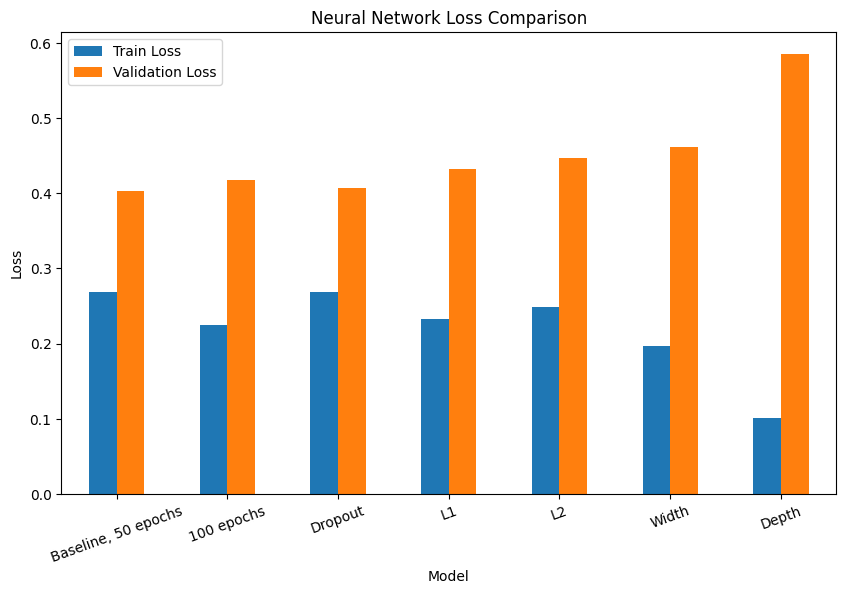

In [852]:
loss_df = summary_df.set_index("Model")[[
    "Train Loss",
    "Validation Loss"
]]

loss_df.plot(kind="bar", figsize=(10, 6))

plt.ylabel("Loss")
plt.title("Neural Network Loss Comparison")
plt.xticks(rotation=20)
plt.legend(loc="best")

plt.show()

## Neural Network conclusions

- 100 epochs and L1 models perfoms the best overall, they have balanced train/validation performance, therefore providing the best generalization among tested configurations
- Increasing the number of epochs improves training accuracy but leads to slight overfitting, as validation performance decreases
- Dropout provides regularization but does not significantly improve performance
- L1 regularization improves generalization
- L2 regularization sligthly reduces model performance, indicating that the baseline model  does not require strong weight penalisation
- Increasing width improved the training accuracy and reduced train loss, but did not improve validation accuracy, indicating that the baseline width was sufficient and wider models tend to overfitting.
- Increasing depth substantially increased training accuracy and reduced training loss, however validation accuracy did not improve and validation loss increased a lot. This means that the deeper network overfits the training data and makes overconfident predictions on unseen data.

## Key insights:
- More training (epochs) => improves performance but risks overfitting
- L1 => improves generalization
- Depth => heavy overfitting
- Width => no major benefit



# Decision tree, logistic regression and neural network comparison

                 Model  Train Accuracy  Test Accuracy  CV Accuracy
0                 Tree        0.897820       0.842391     0.829779
1           Tree Tuned        0.878747       0.836957     0.844795
2  Logistic Regression        0.876022       0.869565     0.863761
3          NN Baseline        0.889267       0.864130          NaN


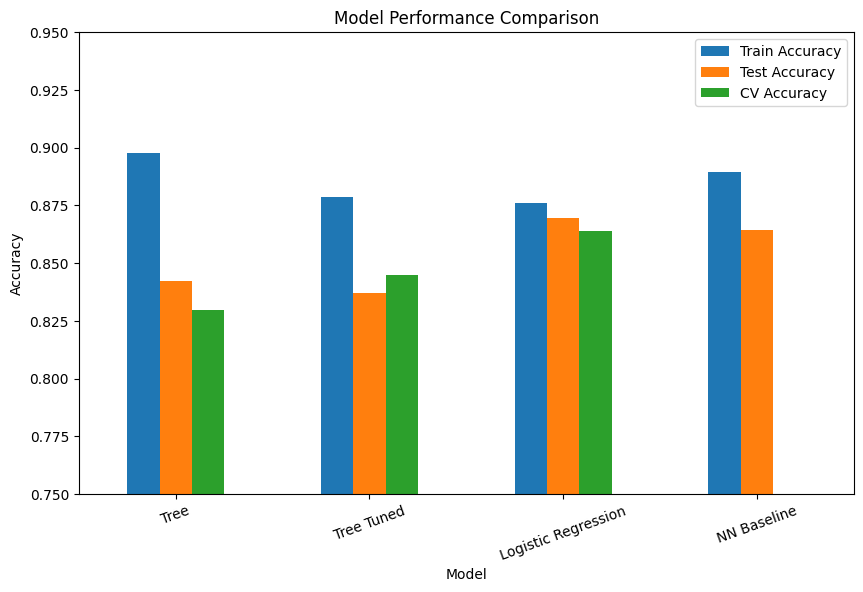

In [853]:
results_df = pd.DataFrame({
    "Model": [
        "Tree",
        "Tree Tuned",
        "Logistic Regression",
        "NN Baseline"
    ],
    "Train Accuracy": [
        train_acc_t,
        train_accuracy_tBest,
        train_accuracy_lr,
        max(history_base.history['accuracy'])
    ],
    "Test Accuracy": [
        test_acc_t,
        test_accuracy_tBest,
        test_accuracy_lr,
        baseline_acc
    ],
    "CV Accuracy": [
        scores_t,
        scores_tBest,
        scores_lr,
        np.nan
    ]
})

print(results_df)

plot_df = results_df.set_index("Model")
plot_df.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.ylim(0.75, 0.95)
plt.legend(loc="best")
plt.show()

# Conclusion
The decision tree model tends to overfit, as training accuracy was significantly higher than test and cross-validation accuracy. Hyperparameter tuning reduced overfitting and improved model stability, although test accuracy decreased sligthly. Logistic regression achieved the highest test accuracy and demonstrated consistent performance across training, test and cross-validation datasets - demonstrating strong generalization and stability. The neural network (baseline model) also performed well but did not ouperform logistic regression and showed sligth overfitting. These results suggest that the dataset is relatively simple and can be effectively modeled using linear methods.

## Key takeaways:
- Logistic regression => best model
- Neural network => unnecessary complexity for this dataset
- Decision tree => prone to overfitting
- Dataset => simple and near-linear